In [1]:
from config.settings import LLM_API_KEY
from src.llm.parser import Receipt,clean_strip
from src.llm.vision import analyze_images_mcp
from src.llm.prompt import vision_prompt
from src.llm.causal import connect_to_minimax
import json
import os
import pandas as pd
from db.connection import connect_db
from db.crud import save_data,read_data

minimax = connect_to_minimax(LLM_API_KEY)

### analyze image

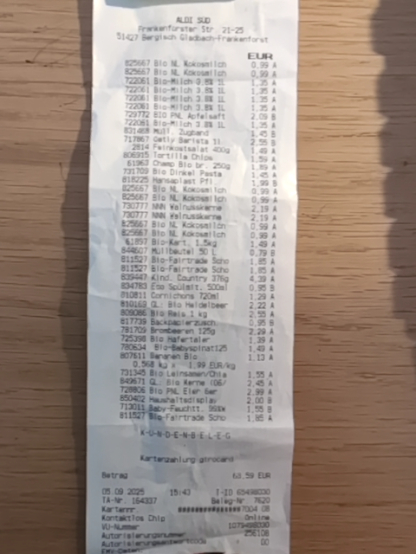

In [2]:
from IPython.display import display, Image
display(Image(filename="src/cloud/data/receipt_20260425_063827.jpg"))

In [3]:
import os

pfad = 'src/cloud/data/'

bilder = [os.path.join(pfad, f) for f in os.listdir(pfad) if f.endswith('.jpg')]

bilder = bilder[:2]

In [4]:
from glob import glob

ergebnisse = analyze_images_mcp(
    image_paths=bilder,
    api_key=LLM_API_KEY,
    prompt=vision_prompt
)


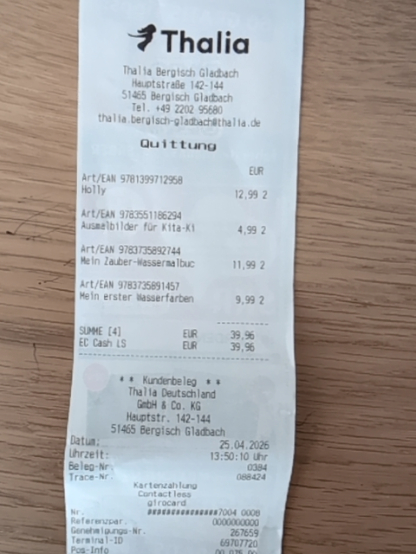

In [5]:
from IPython.display import display, Image
display(Image(filename="src/cloud/data/receipt_20260427_151517.jpg"))


In [6]:
cleaned_results   = [clean_strip(x['text']) for x in ergebnisse]
jsonified_results = [json.loads(x) for x in cleaned_results]
[j['metadata'].update({'source': e['path']}) for j,e in zip(jsonified_results,ergebnisse)]
pydantic_results  = [Receipt.model_validate(x) for x in jsonified_results]


In [7]:
pydantic_results[0]

Receipt(merchant=Merchant(name='HEM Tankstelle Betül Sahin', address='Frankenforster Str. 12, 51427 Bergisch Gladbach', tax_id='DE452377476', phone='02204 / 249337'), transaction=Transaction(date='2024-05-02', time='08:41', currency='EUR', total_amount=53.83, payment_method='girocard', card_last_four='7004', receipt_number='6420'), items=[Item(line_number=1, sku=None, name='Super E10', quantity=26.53, unit='Liter', unit_price=2.029, total_price=53.83, tax_category='A', discount=None, category='Car & Fuel')], taxes=[{'category': 'A', 'rate_percent': 19.0, 'net_amount': 45.24, 'tax_amount': 8.59}], metadata=Metadata(ocr_confidence='high', image_filename=None, source='src/cloud/data/receipt_20260502_145933.jpg'))

### connection

In [8]:
conn, cursor = connect_db('./db/budget_stats.db')

In [9]:
for bill_ in pydantic_results:
    save_data(bill_,cursor,conn,True)
    

[Log] New merchant registered: HEM Tankstelle Betül Sahin
[Log] Successfully processed 1 items for Merchant ID 1.
[Log] New merchant registered: Aldi Süd
[Log] Successfully processed 2 items for Merchant ID 2.


In [10]:
conn.commit()
conn.close()

### read data

In [11]:
from db.crud import read_data
df = read_data('db/budget_stats.db')
df.head()

,id_x,merchant_id,line_number,sku,name,quantity,unit,unit_price,total_price,tax_category,...,payment_method,card_last_four,receipt_number,ocr_confidence,image_filename,id_y,merchant,address,tax_id,phone
0,1,1,1,NaN,Super E10,26.53,Liter,2.029,53.83,A,...,girocard,7004,6420,high,src/cloud/data/receipt_20260502_145933.jpg,1,HEM Tankstelle Betül Sahin,"Frankenforster Str. 12, 51427 Bergisch Gladbach",DE452377476,02204 / 249337
1,2,2,1,317290,Topf Basilikum XL,1.00,NaN,1.990,1.99,A,...,Kartenzahlung,NaN,7531 B355/006/802,high,src/cloud/data/receipt_20260502_145853.jpg,2,Aldi Süd,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",DE 813933044,NaN
2,3,2,2,707489,Riesen Ausmalbuch,2.00,NaN,2.490,4.98,A,...,Kartenzahlung,NaN,7531 B355/006/802,high,src/cloud/data/receipt_20260502_145853.jpg,2,Aldi Süd,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",DE 813933044,NaN


In [5]:
df.columns

Index(['id_x', 'merchant_id', 'line_number', 'sku', 'name_x', 'quantity',
       'unit', 'unit_price', 'total_price', 'tax_category', 'discount',
       'category', 'transaction_date', 'transaction_time', 'currency',
       'total_amount', 'payment_method', 'card_last_four', 'receipt_number',
       'ocr_confidence', 'image_filename', 'id_y', 'name_y', 'address',
       'tax_id', 'phone'],
      dtype='str')

In [9]:
df['transaction_date'].unique()

<ArrowStringArray>
['2023-05-02', '2026-05-02', nan, '2024-04-25', '2026-04-25', '2023-09-05']
Length: 6, dtype: str

In [10]:
df[df['transaction_date'] == '2023-05-02']

,id_x,merchant_id,line_number,sku,name,quantity,unit,unit_price,total_price,tax_category,...,payment_method,card_last_four,receipt_number,ocr_confidence,image_filename,id_y,merchant,address,tax_id,phone
0,1,1,1,NaN,Super E10,26.530,Liter,2.029,53.83,A,...,girocard,7004,6420,high,NaN,1,HEM Tankstelle,"Frankenforster Str. 12, 51427 Bergisch Gladbach",DE452377476,02204 / 249337
3,4,3,1,536425,Bio-Apfelsaft 1l,1.000,l,1.550,1.55,B,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
4,5,3,2,290288,Oatly Haferdrink,1.000,NaN,2.550,2.55,B,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
5,6,3,3,NaN,Eigenmarke: Pfand,NaN,NaN,NaN,-1.50,B,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
6,7,3,4,203603,BB Heumil 3.8% 1L,1.000,L,1.450,1.45,A,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
7,8,3,5,203603,BB Heumil 3.8% 1L,1.000,L,1.450,1.45,A,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
8,9,3,6,203603,BB Heumil 3.8% 1L,1.000,L,1.450,1.45,A,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
9,10,3,7,203603,BB Heumil 3.8% 1L,1.000,L,1.450,1.45,A,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
10,11,3,8,536425,Bio-Apfelsaft 1l,1.000,l,1.550,1.55,B,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
11,12,3,9,357806,Bad Reic AlpenSalz,NaN,NaN,0.750,0.75,A,...,girocard,7004,1270,high,NaN,3,ALDI SÜD,"Frankenforster Str. 25, 51427 Bergisch Gladbac...",NaN,NaN
